# TELCO CUSTOMER CHURN

## Objective
The goal of this notebook is to understand what drives customer churn in a telecommunications company, identify the highest risk customer segments, and build a predictive model that can flag customers who are likely to leave before they actually do.

##  Dataset

- Source: IBM Sample Dataset 
- Size: 7,043 customers × 21 features
- Target variable: Churn — whether the customer left within the last month (Yes / No)

## Notebook Structure

- Importing Libraries & Loading Data
- Data Cleaning & Missing Values
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Feature Engineering
- Feature Selection
- Model Building
- Model Evaluation & Comparison
- Key Insights & Business Recommendations

## 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score , f1_score , confusion_matrix , classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRFClassifier, XGBClassifier
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV ,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
os.listdir('/kaggle/input/datasets/blastchar/telco-customer-churn')

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [4]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# transfer object values to float to let pd identfy the NaN values
'MonthlyCharges' ,
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors= 'coerce')

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

here we notice that we had to change Totalcharge to Numeric to let pandas identfy the **NAN** Values

In [8]:

df = df.fillna(df['TotalCharges'].mean())

i just gonna fill The missing values with Average since they are only 11 values

In [9]:
# drop customerId columns
df = df.drop('customerID' , axis = 1 )



In [10]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({1 :'yes' , 0 : 'no'})

# Numeric columns
numeric_columns = df[df.select_dtypes([int , float]).columns]

numeric_columns.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2265.000258
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1400.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


# EDA 

## Univariate Analysis

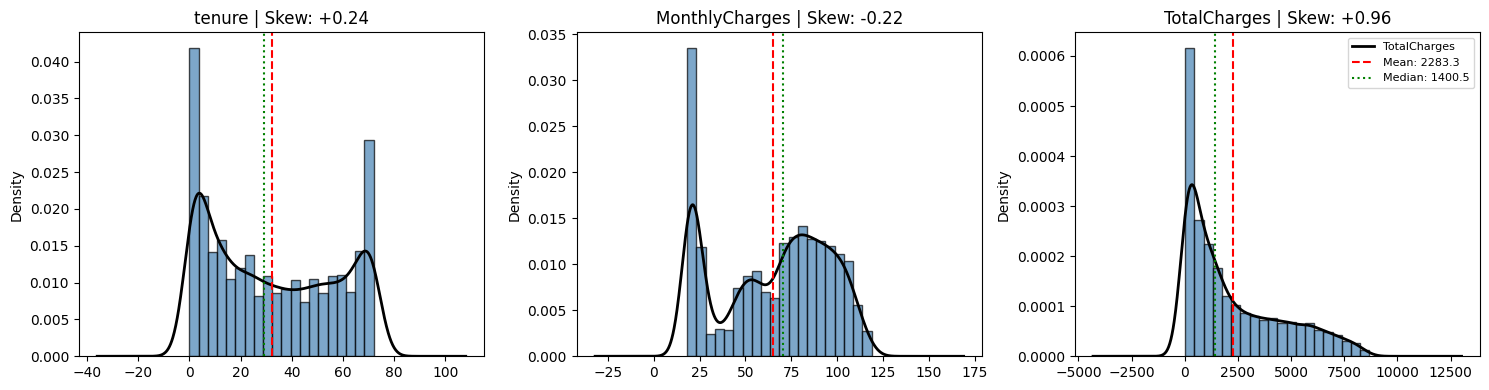

In [11]:
from scipy.stats import skew, kurtosis

ig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_columns):
  df[col].hist(ax=ax, bins=20, density=True,
  color='steelblue', alpha=0.7, edgecolor='black')

  df[col].plot.kde(ax=ax, color='black', lw=2)
  # mean v line
  ax.axvline(df[col].mean(), color='red', ls='--', lw=1.5,
  label=f'Mean: {df[col].mean():.1f}')
  # median v line
  ax.axvline(df[col].median(), color='green', ls=':', lw=1.5,
  label=f'Median: {df[col].median():.1f}')
  sk = skew(df[col])
  ax.set_title(f'{col} | Skew: {sk:+.2f}')


ax.legend(fontsize=8)
plt.tight_layout()

- **TotalCharges** Stong Right skew
- **tenure** spikes at new(0-6) , and loyal(70-75)

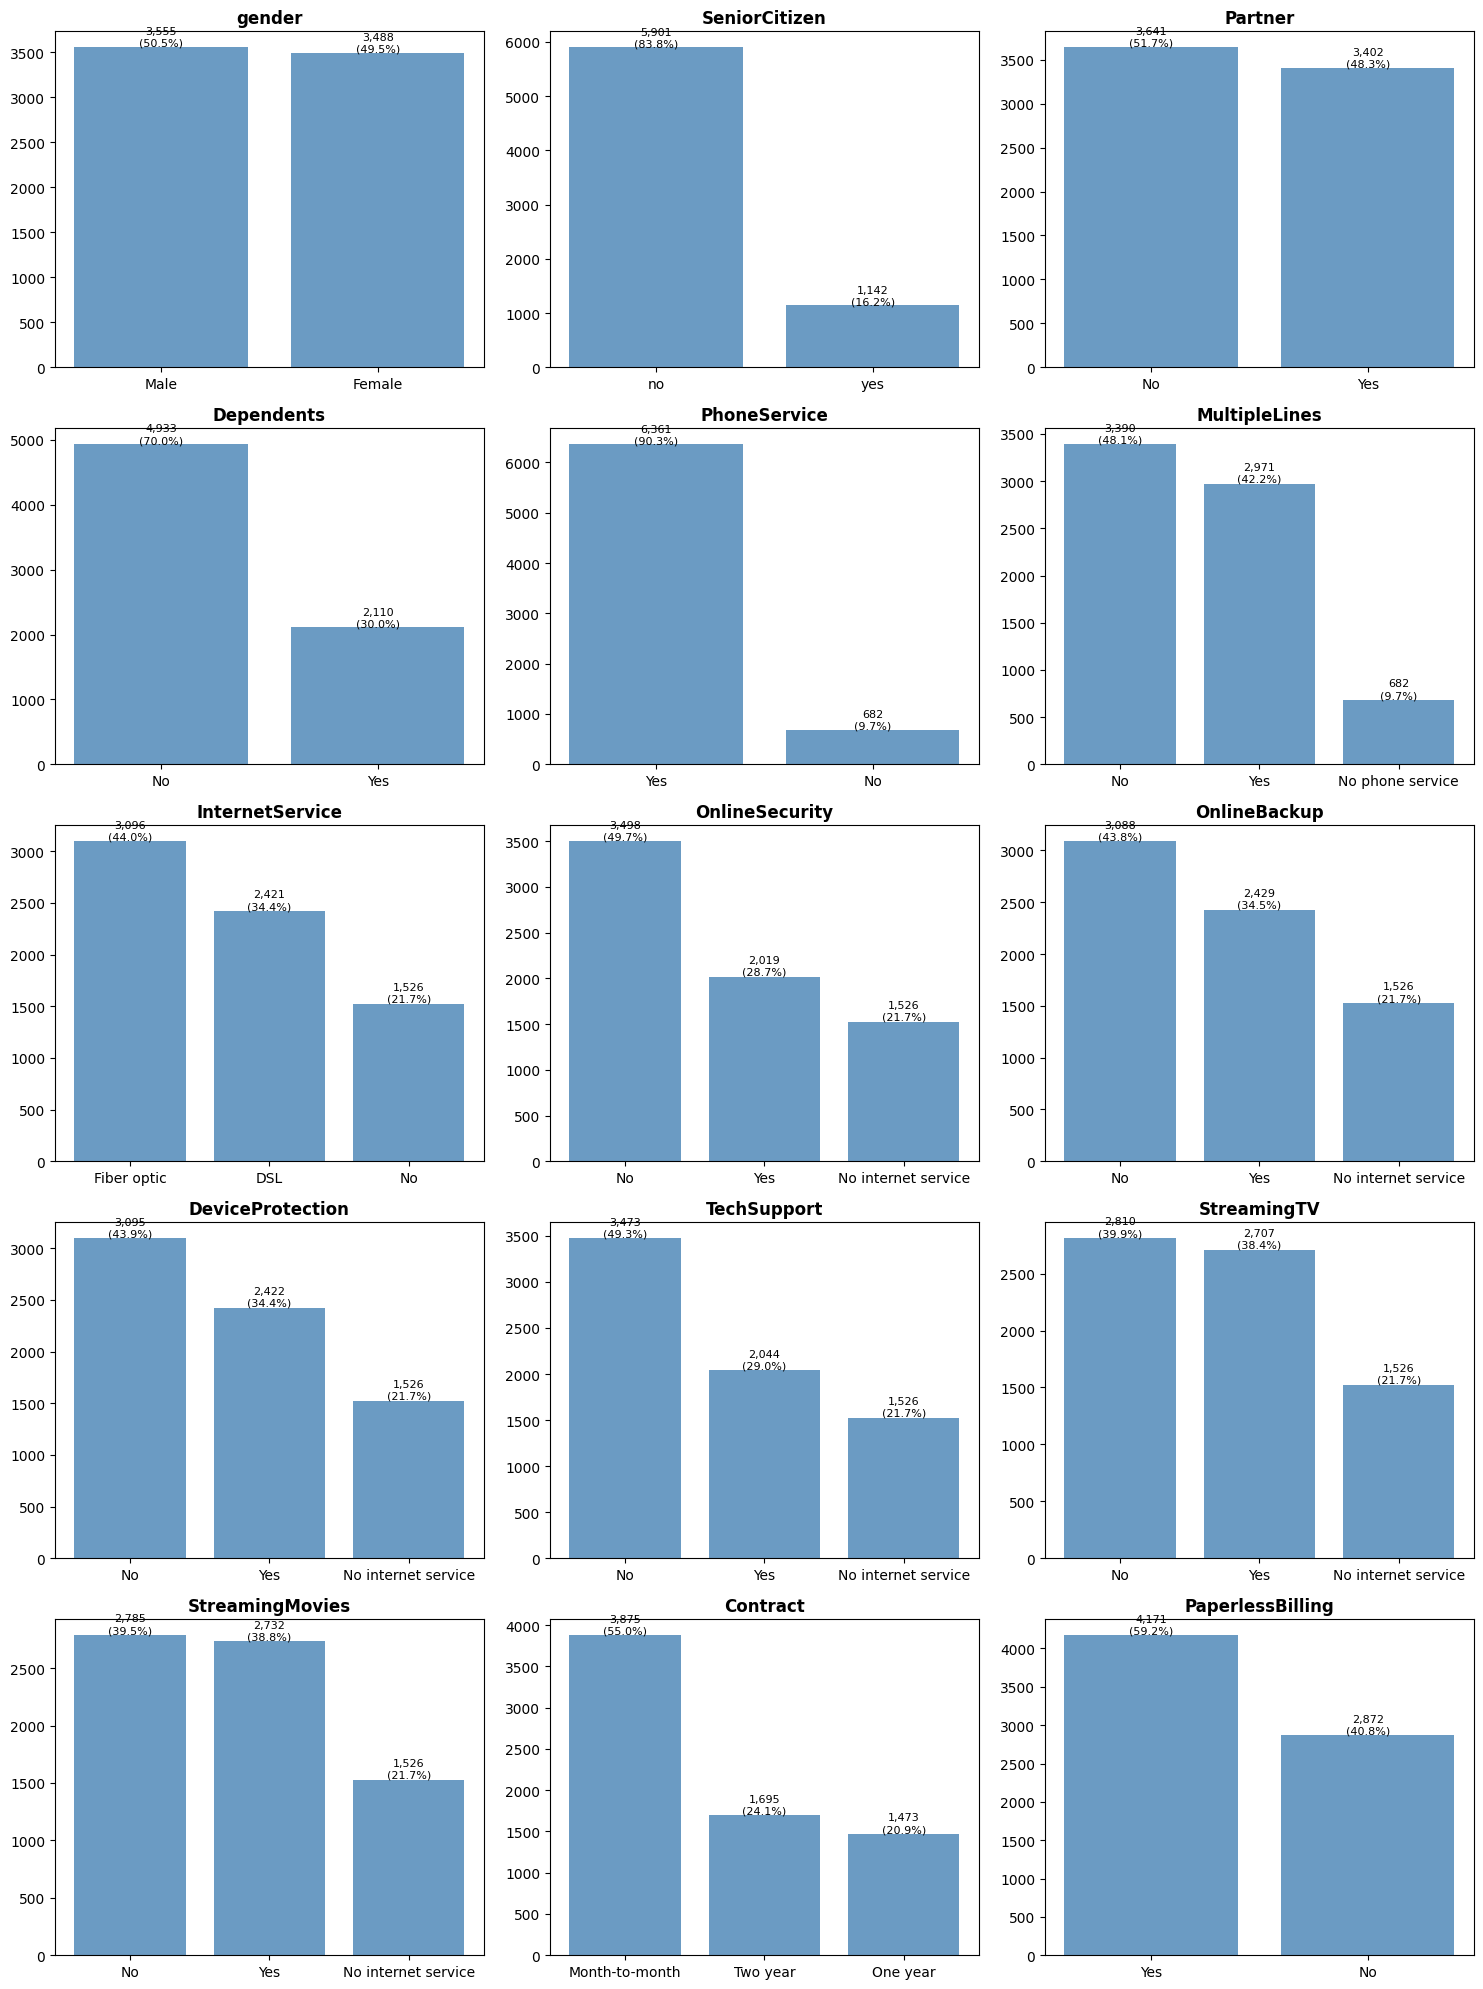

In [12]:
non_numeric_col =  [col for col in df.columns if col not in numeric_columns]
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for ax, col in zip(axes.flatten(), non_numeric_col):
  vc = df[col].value_counts()
  pct = vc / len(df) * 100
  bars = ax.bar(vc.index, vc.values, color='steelblue', alpha=0.8)
  for bar, (cnt, p) in zip(bars, zip(vc.values, pct.values)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
    f'{cnt:,}\n({p:.1f}%)', ha='center', fontsize=8)
    ax.set_title(col, fontweight='bold')
plt.tight_layout()

- **gender** 50/50 no bias


## Bivariate Analysis

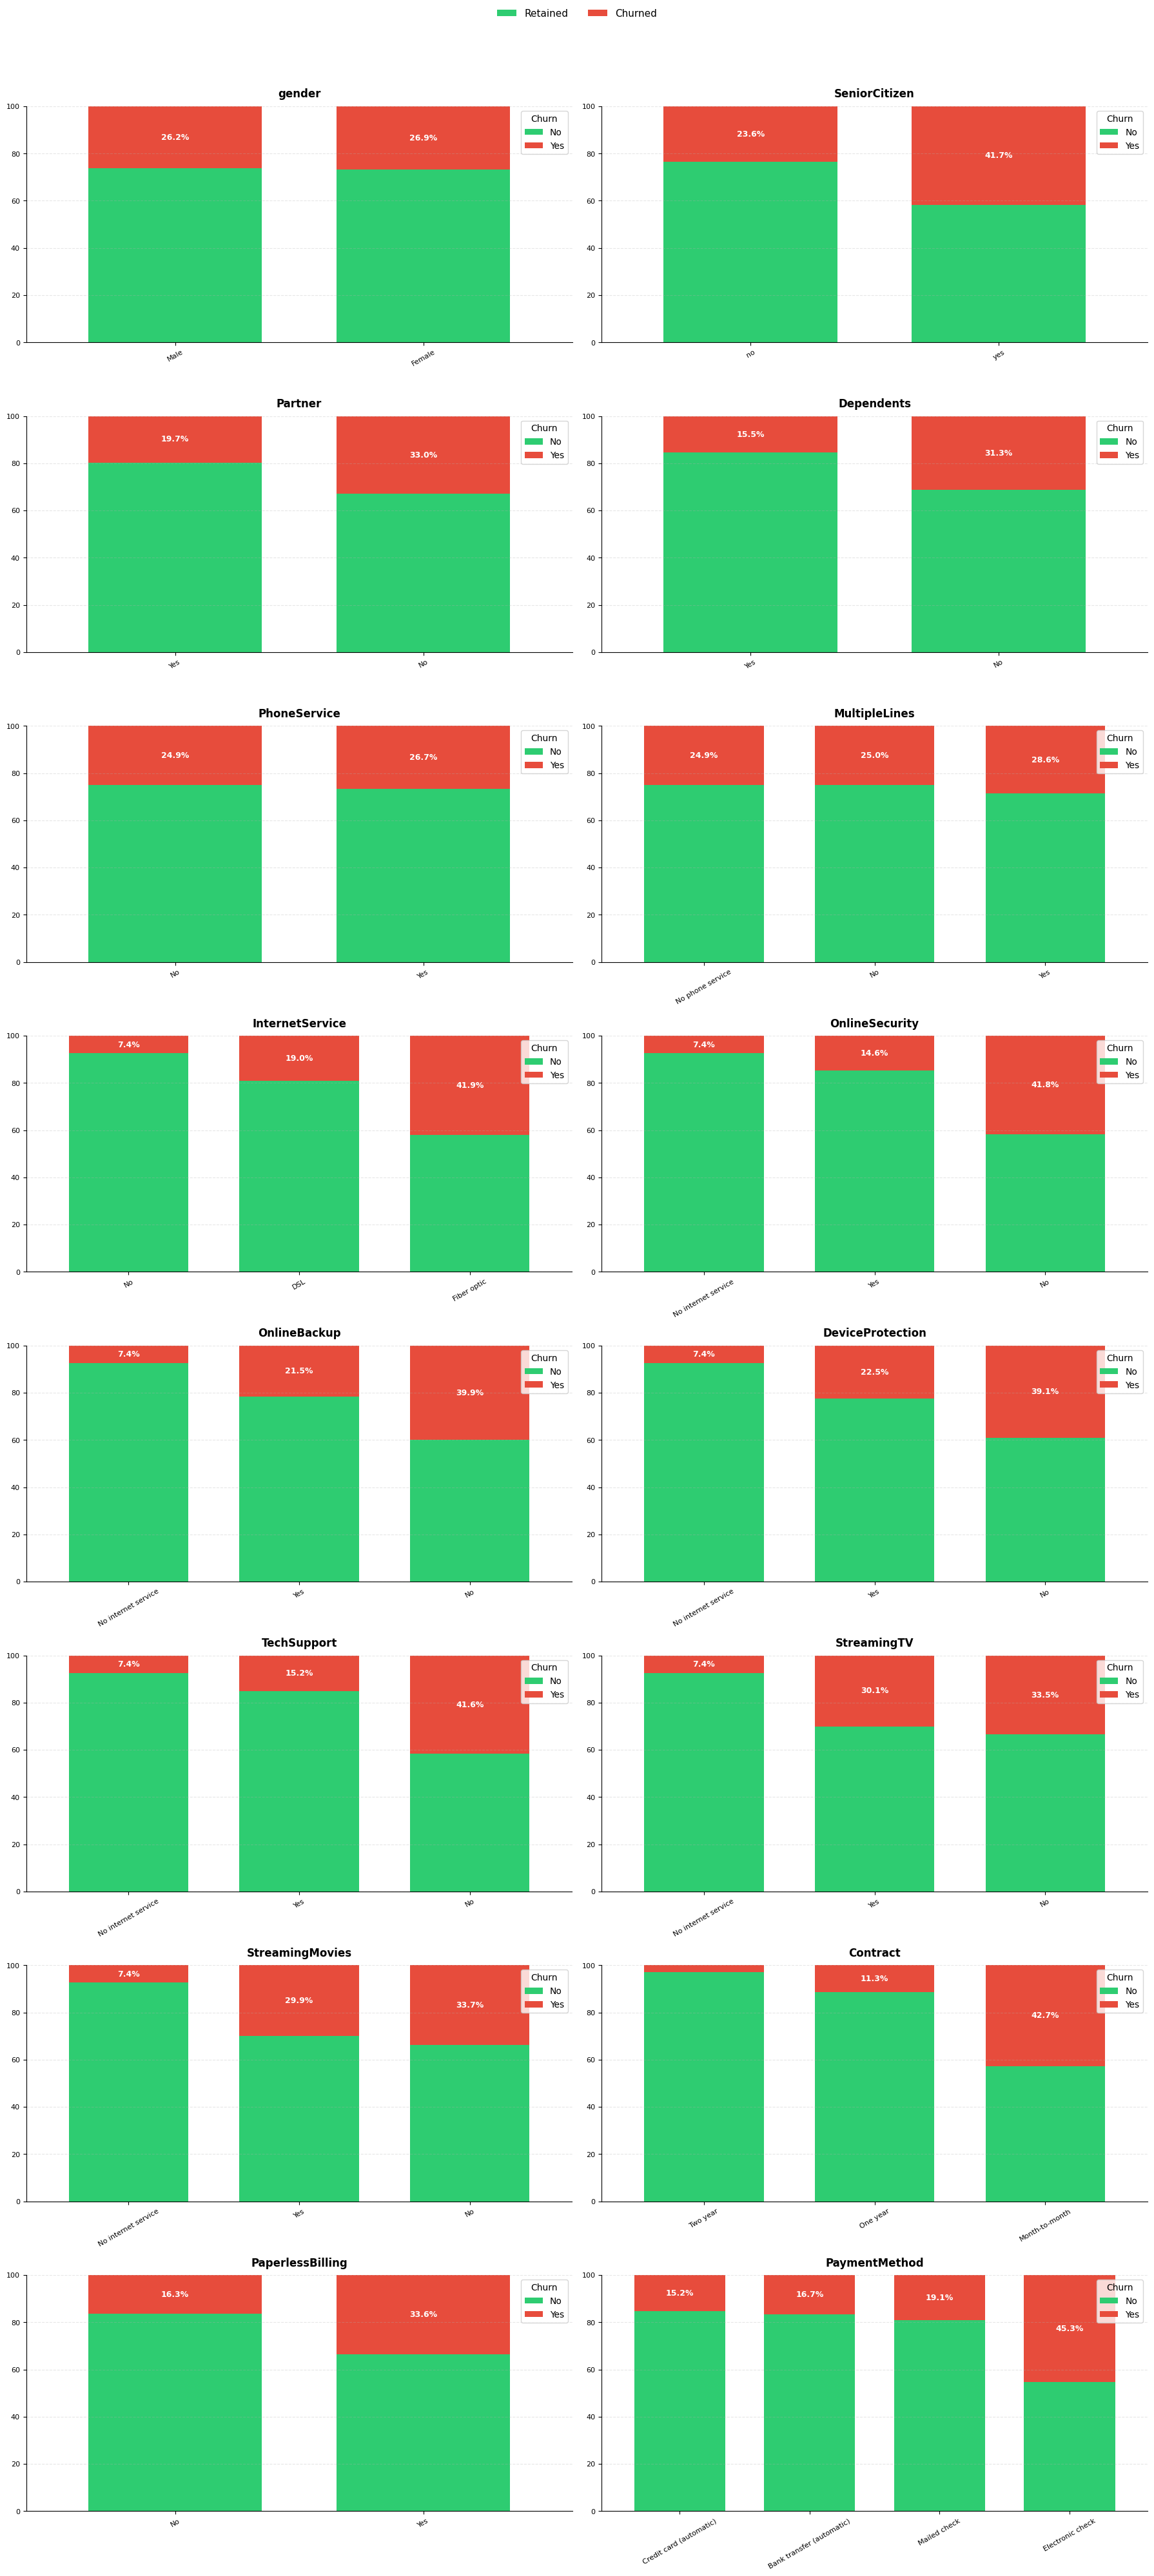

In [13]:

non_numeric_col =  [col for col in df.columns if col not in numeric_columns]

fig, axes = plt.subplots(8, 2, figsize=(18, 40))
axes = axes.flatten()

for ax, feat in zip(axes, non_numeric_col):
    ct = pd.crosstab(df[feat], df['Churn'], normalize='index') * 100

    # Sort by churn for
    ct = ct.sort_values(by='Yes')

    # Plot
    ct.plot(kind='bar',
            stacked=True,
            ax=ax,
            color=['#2ECC71', '#E74C3C'],
            edgecolor='none',
            width=0.7)

    # Add churn % labels
    for i, (idx, row) in enumerate(ct.iterrows()):
        churn = row['Yes']
        retained = row['No']


        if churn > 5:
            ax.text(i,
                    retained + churn / 2,
                    f"{churn:.1f}%",
                    ha='center',
                    va='center',
                    fontsize=9,
                    color='white',
                    fontweight='bold')


    ax.set_title(feat, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(0, 100)


    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    # Remove top right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    ax.yaxis.grid(True, linestyle='--', alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, ['Retained', 'Churned'],
           loc='upper center',
           ncol=2,
           fontsize=11,
           frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])

os.makedirs('content', exist_ok=True)
plt.savefig('content/churn_analysisd.png')
plt.show()

Key Insights:

- **Gender** doesn't affect the churn decision — both Male and Female sit at around 26%
- **Senior citizens** are more likely to churn (41.7%) compared to non-seniors (23.8%).
- **Electronic check** users have the highest churn risk at (45.3%) — that's around **3×** higher than all other payment methods.
- **Two-year** contract customers have the lowest churn risk (11.3%).
- **Month-to-month** contract customers have the highest churn risk at (42.7%).
- **Fiber optic** subscribers have a surprisingly high churn rate of (41.9%) — more than **double** the DSL rate (19.0%)
- **Paperless billing** customers churn at (33.9%) — about **2×** higher than non-paperless customers (16.3%).
- Customers without a **partner** churn more (33.0%) than those with a partner (19.7%).
Customers without **dependents** churn more (31.3%) than those with dependents (15.5%).



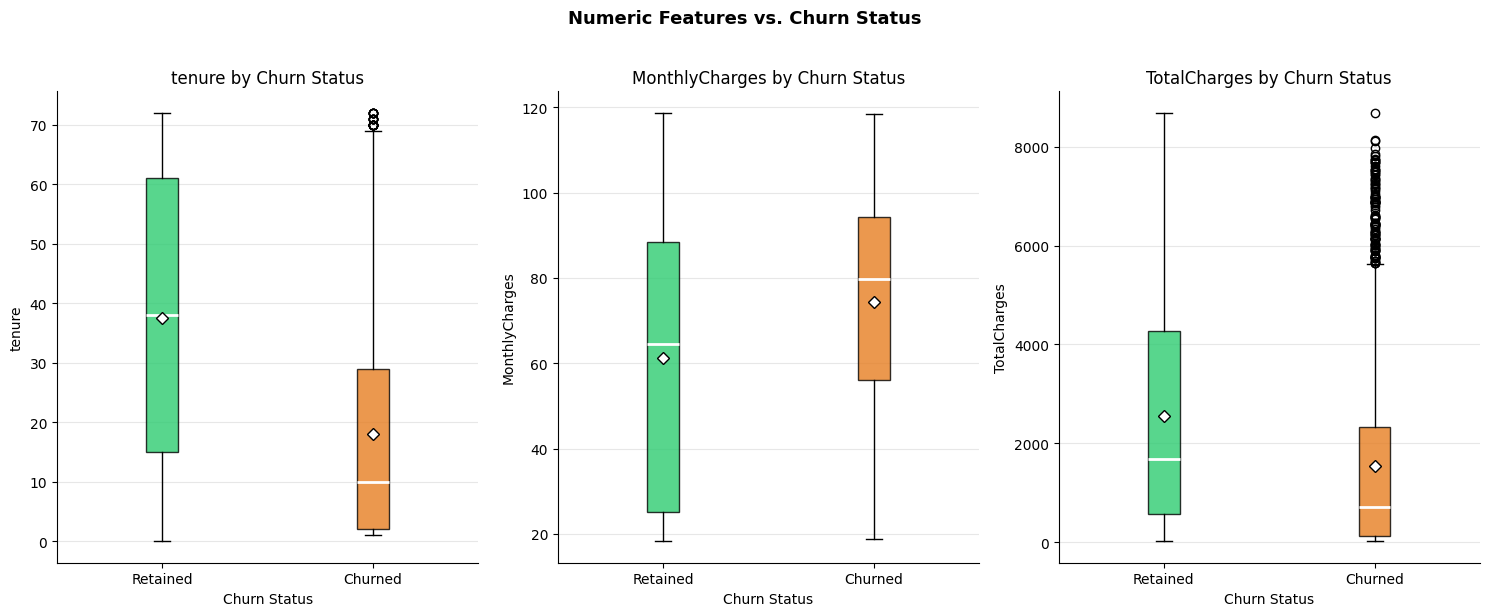

In [14]:
#Box plot for the numceric columns

fig, axs = plt.subplots(1, 3, figsize=(15, 6))

for ax, col in zip(axs.flatten(), numeric_columns):

    groups = [df[df['Churn'] == 'No'][col],
              df[df['Churn'] == 'Yes'][col]]

    bp = ax.boxplot(groups,
                    patch_artist=True,
                    tick_labels=['Retained', 'Churned'],
                    medianprops=dict(color='white', lw=2))


    colors = ['#2ecc71', '#e67e22']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)


    for i, group in enumerate(groups, 1):
        ax.plot(i, group.mean(), marker='D', color='white',
                markersize=6, zorder=5, markeredgecolor='black')

    ax.set_xlabel('Churn Status')
    ax.set_ylabel(col)
    ax.set_title(f'{col} by Churn Status')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Numeric Features vs. Churn Status',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("/content/nmeric_feature_churn status")
plt.show()

**Key Findings**
- **Tenure** ----------------------------------------------------
- Customers are highly likely to churn in the first 6–12 months
- Retained customers stay on average 38 months while churned customers leave after only 18 month

- **MonthChanges**---------------------------------------------
- Churned customers pay more on average (75/month)while_retained_customers pay $61/month

- **TotalCharges**---------------------------------------------
- Retained customers have higher total charges (2,400) while churned customers have (1,400)

- This is mostly because retained customers simply stayed longer, so they accumulated more charges over time



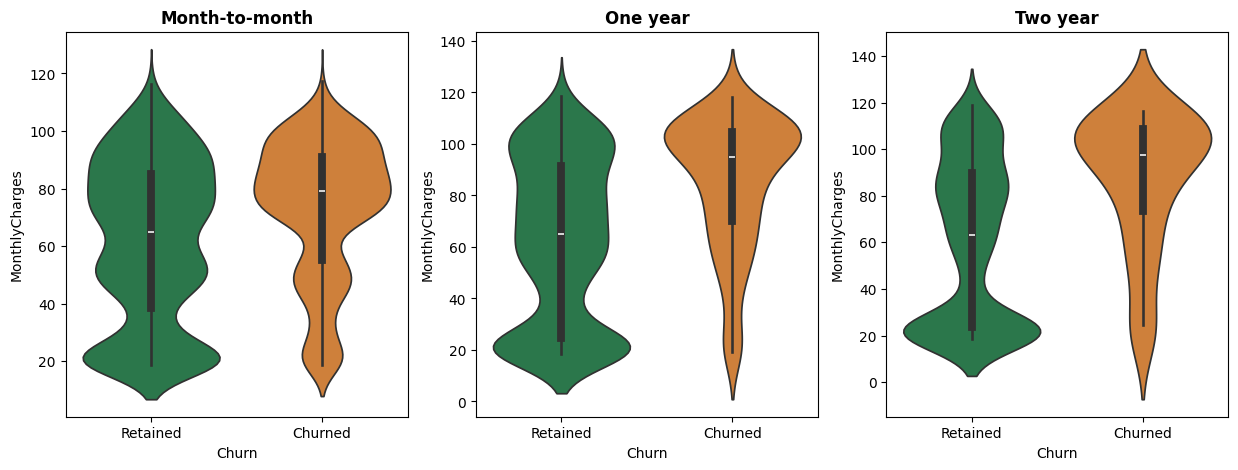

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
contracts = df['Contract'].unique()
for ax, contract in zip(axes, contracts):
  sub = df[df['Contract'] == contract]
  sns.violinplot(data=sub, x='Churn', y='MonthlyCharges', hue='Churn',
  palette={'No':'#1E8449', 'Yes':'#E67E22'} ,
          inner='box', ax=ax, legend=False)
  ax.set_title(contract, fontweight='bold')
  ax.set_xticklabels(['Retained','Churned'])
plt.savefig('content/violetplot')

- we see that monthly charge correlate with churn , higher monthly charge increase the churn risk

- customer who paying low monthly charge  arround (20) are the most **Loyal**
- customer who paying low monthly charge  arround (70 - 100) are the most  **Churners**

## Multivariate analysis

<Axes: >

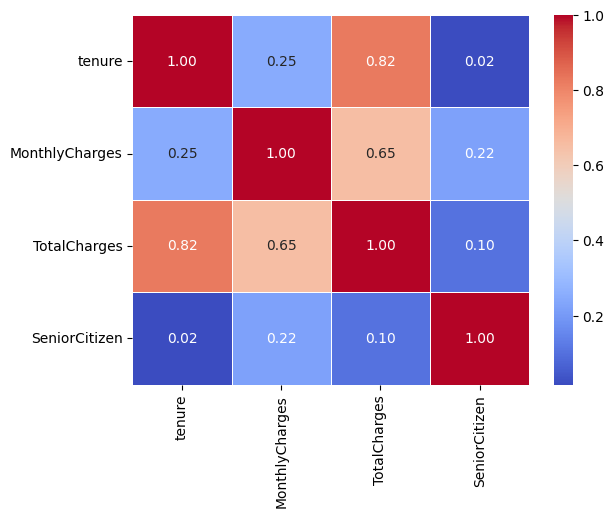

In [16]:

corr_cols = ['tenure','MonthlyCharges','TotalCharges', 'SeniorCitizen']

temp_df_for_corr = df[corr_cols].copy()
temp_df_for_corr['SeniorCitizen'] = temp_df_for_corr['SeniorCitizen'].map({'yes': 1, 'no': 0})

correlation_matrix = temp_df_for_corr.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

- TotalCharge has a high correlation with the tenure


/tmp/ipykernel_23/640387519.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pair_df['Churn'] = pair_df['Churn'].map({'No':'Retained','Yes':'Churned'})


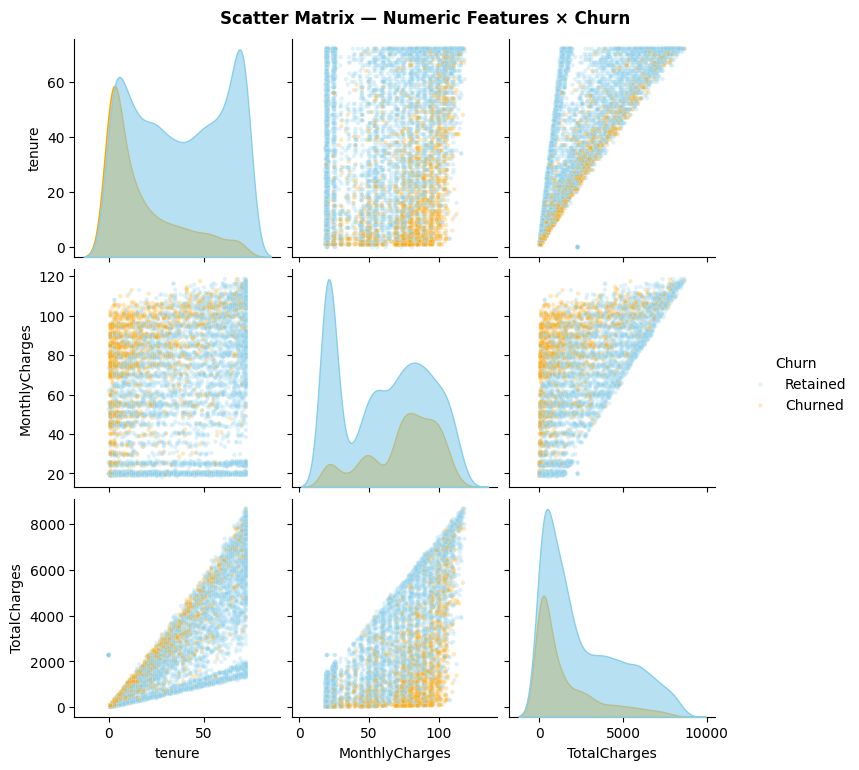

In [17]:
# Pair plot

pair_df = df[['tenure','MonthlyCharges','TotalCharges','Churn']]
pair_df['Churn'] = pair_df['Churn'].map({'No':'Retained','Yes':'Churned'})
g = sns.pairplot(pair_df, hue='Churn',
palette={'Retained':'skyblue','Churned':'orange'},
diag_kind='kde',
plot_kws={'alpha':0.25, 's':10},
diag_kws={'alpha':0.6})
g.fig.suptitle('Scatter Matrix — Numeric Features × Churn',
y=1.02, fontsize=12, fontweight='bold')
plt.savefig('content/pairtplot')


- Low tenure and high MonthlyCharges  = **High churn risk**
- the Longer you stay the higher  Toatalcharges

# Feature Engineering

Encode Categorical Variabless

In [18]:

def add_features (df) :

    # add Number of services feature
    num_services = service_cols = ['OnlineSecurity_Yes','OnlineBackup_Yes',
      'DeviceProtection_Yes','TechSupport_Yes',
      'StreamingTV_Yes','StreamingMovies_Yes']

    df['Num_of_services'] = df[[c for c in num_services if c in df.columns]].sum(axis = 1)


    # add tenure bucket

    df['tenure_bucket'] = pd.cut(df['tenure'] ,
                          bins =[0 ,6 , 12 ,24 ,36 ,48 ,60,72]  ,
                          labels=['0-6m','7-12m','13-24m','25-36m','37-48m','49-60m','60m+'] )

    return df

df = add_features(df)

In [19]:
def encode_categorical(df):

  # binary Encoding
  binary_features  = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
  le = LabelEncoder()
  for col in binary_features :
    df[col] = le.fit_transform(df[col])

  # OneHot Encoding

  onehot_features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod','tenure_bucket']

  df =  pd.get_dummies(df , onehot_features , drop_first=True)


  return df

df = encode_categorical(df)


In [20]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'Num_of_services', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'tenure_bucket_7-12m', 'tenure_bucket_13-24m', 'tenure_bucket_25-36m',
       'tenure_bucket_37-48m', 'tenure_bucket_49-60m', 'tenure_buc

## Features Selection

 **Split data**

In [21]:
Y = df['Churn']
X = df.drop('Churn' , axis =1)

X_train , X_ , y_train , y_ = train_test_split(X ,Y , test_size=0.4 ,random_state=42 , stratify=Y)

X_val , X_test , y_val , y_test = train_test_split(X_ ,y_ , test_size=0.2 ,random_state=42 , stratify=y_)

**Variance Threshold**

In [22]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)


selector.fit(X_train)

Low_variance = X_train.columns[~selector.get_support()].tolist()

print (Low_variance)

['Num_of_services']


# Modeling

**CrossValidation**

In [23]:
from sklearn.model_selection import KFold
from sklearn.base import clone

kf = KFold(n_splits = 5 , shuffle = True , random_state = 42)

In [24]:
def evaluation_function (name , model , X_train , y_train, X_val , y_val, kf) :

  """
  Evaluate The model
    - Apply CrossValidation To See how the Model will Generlize (how it work with unseen data)
    - Calc The accuracy
    - Check The overfiting BY comparing the Train accuracy and Validation
  """
  cv = []
  for train_idx , val_idx in kf.split(X_train) :

      X_tr = X_train.iloc[train_idx]
      y_tr = y_train.iloc[train_idx]
      X_vl = X_train.iloc[val_idx]
      y_vl = y_train.iloc[val_idx]

      model1 = clone(model)
      model1.fit(X_tr , y_tr)
      pred = model1.predict(X_vl)
      acc = accuracy_score(y_true=y_vl , y_pred= pred)
      cv.append(acc)

  # calc the average cross validation score
  cv_acc = np.mean(cv)

  model.fit(X_train , y_train)

  train_acc = accuracy_score(y_train, model.predict(X_train))
  val_acc   = accuracy_score(y_val,   model.predict(X_val))


  print(f"{name}:")
  print(f"  CV Acc    : {cv_acc:.2f}% \u00b1 {np.std(cv):.4f}")
  print(f"  Train Acc : {train_acc:.2f}%")
  print(f"  Val Acc   : {val_acc:.2f}%")

  return cv_acc , val_acc , model

- **Logistic Regression Model**

In [25]:
lr_params = {"C": np.logspace(-4, 4, 20),
          "solver": ["liblinear"]}


lr_grid = GridSearchCV(
    LogisticRegression() ,
    lr_params ,
    cv = 5 ,
    scoring = 'accuracy' ,
    n_jobs = -1

)

lr_grid.fit(X_train , y_train)

best_lr = lr_grid.best_estimator_
lr_params = lr_grid.best_estimator_

print (f"best lr params  : {lr_params}")

lr_cv ,lr_vl,lr_model =  evaluation_function("Logistic_Regression" , best_lr , X_train , y_train, X_val , y_val, kf)



best lr params  : LogisticRegression(C=np.float64(0.23357214690901212), solver='liblinear')
Logistic_Regression:
  CV Acc    : 0.80% ± 0.0099
  Train Acc : 0.81%
  Val Acc   : 0.81%


- **KNN CLASSIFIER**

In [26]:



Knn_params = {
    'n_neighbors' : [1 ,2 ,3 ,4 ,5 ,6 ,7 ,8, 9,10 ,11 , 12 ,13 ,14 ,15 ]
}

Knn_grid = GridSearchCV(
    KNeighborsClassifier() ,
    Knn_params ,
    cv = 5 ,
    scoring = 'accuracy' ,
    n_jobs = -1

)

Knn_grid.fit(X_train ,y_train)

best_knn = Knn_grid.best_estimator_
best_params = Knn_grid.best_params_

print (f"KNN Best Params is :  {best_params}")

knn_cv ,knn_vl,knn_model =  evaluation_function("KNN Classifier" , best_knn , X_train , y_train, X_val , y_val, kf)

KNN Best Params is :  {'n_neighbors': 12}
KNN Classifier:
  CV Acc    : 0.78% ± 0.0125
  Train Acc : 0.81%
  Val Acc   : 0.78%


- **Random Forest**

In [27]:


rf_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state =42 , n_jobs=-1) ,
    rf_params ,
        cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_params = rf_grid.best_params_

print ("best_params are : \t" , rf_params)

rf_cv ,rf_vl,rf_model =  evaluation_function("Random_Forest" , rf_best , X_train , y_train, X_val , y_val, kf)

best_params are : 	 {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 500}
Random_Forest:
  CV Acc    : 0.80% ± 0.0036
  Train Acc : 0.85%
  Val Acc   : 0.80%


- **XGBOOST**

In [28]:
from scipy import stats

xgb_params = dict(
    n_estimators=stats.randint(10, 1000),
    max_depth=stats.randint(1, 10),
    learning_rate=stats.uniform(0, 1)
)

xgb_clf = XGBClassifier()

xgb_rand = RandomizedSearchCV(
    xgb_clf, xgb_params, cv=5, n_iter=150,
    scoring='accuracy', n_jobs=-1, verbose=1
)

xgb_rand.fit(X_train, y_train)

xgb_best = xgb_rand.best_estimator_
xgb_params = xgb_rand.best_params_

print ("best_params are : \t" , xgb_params)

xgb_cv ,xgv_vl,xgb_model =  evaluation_function("XGBOOST" , xgb_best , X_train , y_train, X_val , y_val, kf)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
best_params are : 	 {'learning_rate': np.float64(0.2335414325324574), 'max_depth': 1, 'n_estimators': 370}
XGBOOST:
  CV Acc    : 0.81% ± 0.0096
  Train Acc : 0.81%
  Val Acc   : 0.81%


- **CatBoost**

In [29]:
# Catboost

!pip install catboost
from catboost import CatBoostClassifier

best_cat = CatBoostClassifier(
    iterations    = 1000,
    learning_rate = 0.03,
    depth         = 6,
    l2_leaf_reg   = 3,
    random_seed   = 42,
    eval_metric   = 'Accuracy',
    verbose       = False
)

best_cat.fit(
    X_train, y_train,
    eval_set            = (X_val, y_val),
    early_stopping_rounds = 50
)

cat_cv, cat_val, best_cat =  evaluation_function(
    'CatBoost', best_cat, X_train, y_train, X_val, y_val, kf
)

CatBoost:
  CV Acc    : 0.79% ± 0.0057
  Train Acc : 0.92%
  Val Acc   : 0.80%


- **GBM**

In [30]:
from sklearn.ensemble import GradientBoostingClassifier


gbm_params = {
    "n_estimators": [100, 300],
    "learning_rate": [0.001,0.01, 0.05, 0.1 ],
    "max_depth": [2,3]
}

gbm_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gbm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gbm_grid.fit(X_train, y_train)

best_gbm = gbm_grid.best_estimator_
best_gbm_params = gbm_grid.best_params_

print(f"Best GBM params: {best_gbm_params}")

gbm_cv, gbm_val, best_gbm = evaluation_function(
    "GBM", best_gbm, X_train, y_train, X_val, y_val, kf
)

Best GBM params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300}
GBM:
  CV Acc    : 0.80% ± 0.0047
  Train Acc : 0.82%
  Val Acc   : 0.80%


In [31]:
results = pd.DataFrame (
    {
        'models' : ['Logistic Regression' , 'KNN Classifier' , 'Random Forest' , 'Xgboost' , 'Catboost' , 'Gbm'],
        'accuracy' : [lr_vl , knn_vl , rf_vl , xgv_vl , cat_val , gbm_val],
        'cv_acc'  : [lr_cv , knn_cv , rf_cv , xgb_cv , cat_cv , gbm_cv],
    }
)


display (results.sort_values(by = 'accuracy' ,ascending=False))

,models,accuracy,cv_acc
3,Xgboost,0.810115,0.806154
0,Logistic Regression,0.809672,0.803077
5,Gbm,0.803461,0.804260
2,Random Forest,0.800799,0.798817
4,Catboost,0.797693,0.791953
1,KNN Classifier,0.777285,0.780118


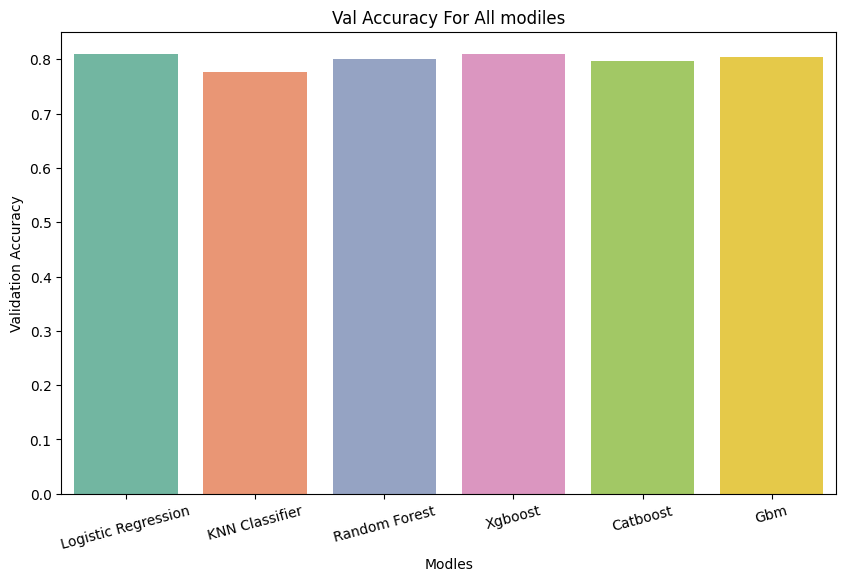

In [32]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,6))
sns.barplot (results , x = 'models' , y = 'accuracy' , palette='Set2')
plt.title ('Val Accuracy For All modiles')
plt.xlabel ('Modles')
plt.ylabel('Validation Accuracy')
plt.xticks(rotation = 15)
plt.show()

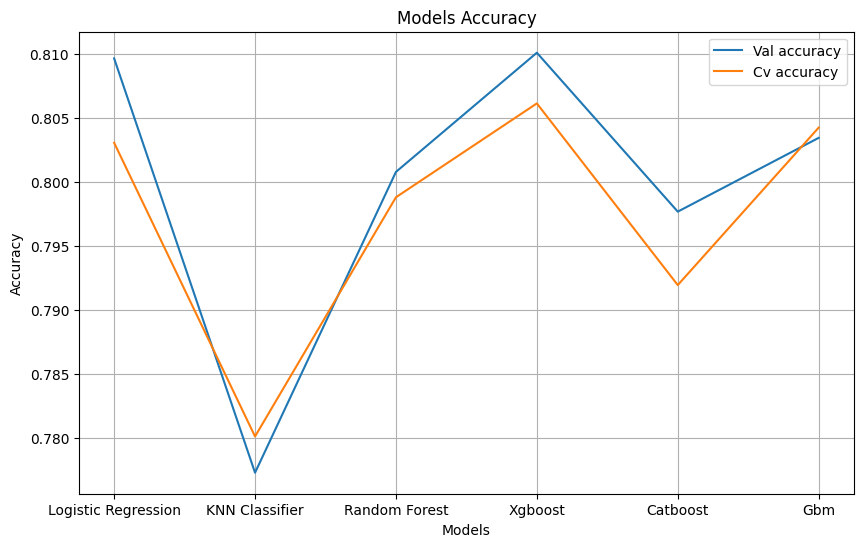

In [33]:
plt.figure(figsize=(10,6))
plt.plot(results['models'] , results['accuracy'] ,label ='Val accuracy')
plt.plot(results['models'] , results['cv_acc'] , label = 'Cv accuracy')

plt.title("Models Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

## Feature Importance 

In [34]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_val)
np.shape(shap_values.values)

(2254, 37)

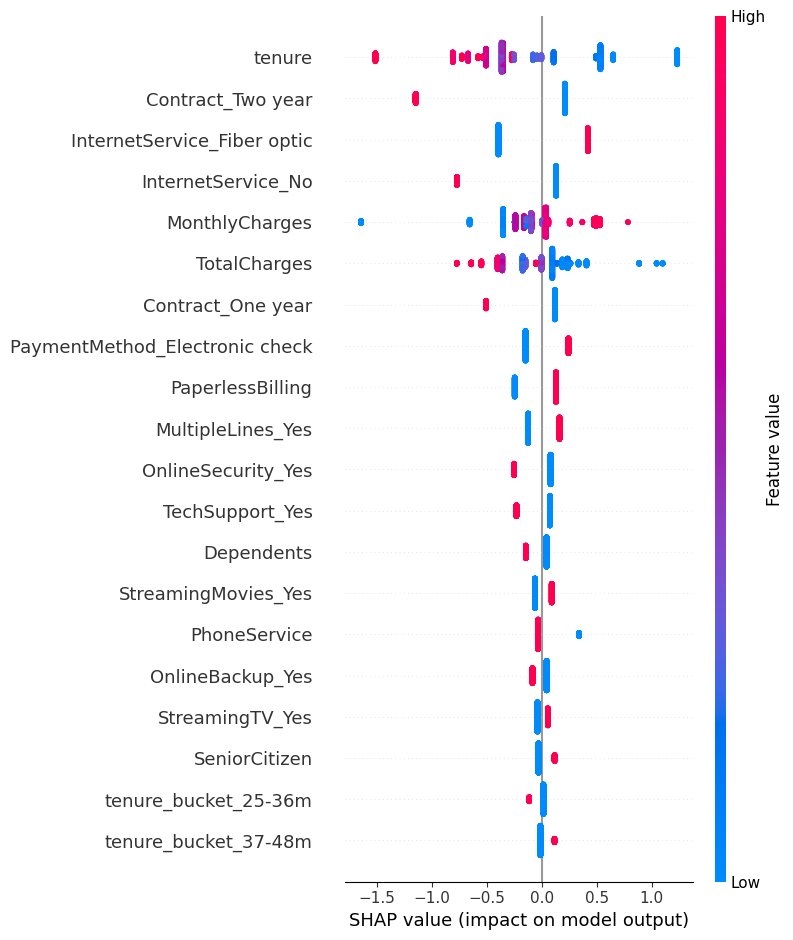

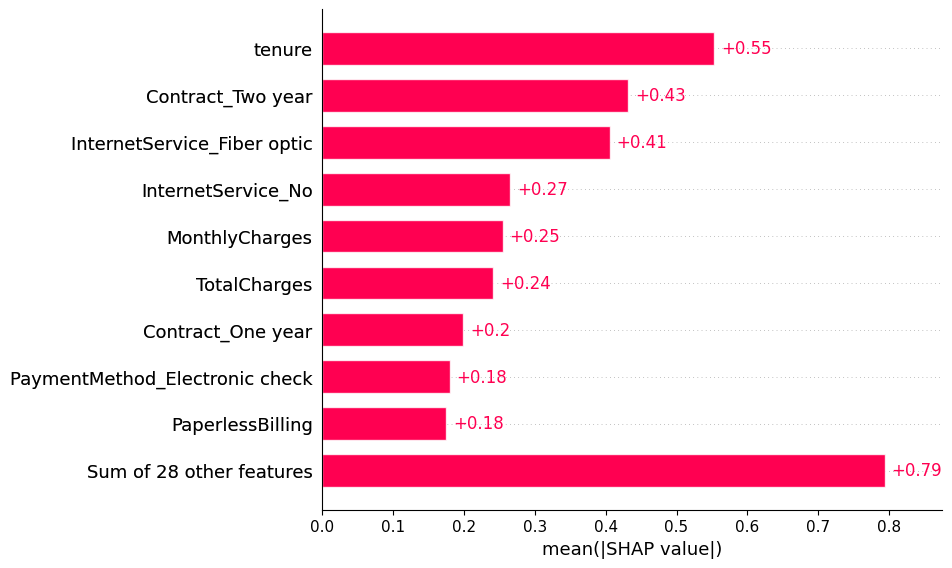

In [35]:
shap.summary_plot(shap_values)
shap.plots.bar(shap_values)

- we notice that the Tenure is The most importance feature for the model

- the two years contract  significantly reduces churn prediction

- and having no internet service or low Monthly Charge  reduce churn prediction either
  

# Conclusion & Key Insights

## customer profile most likely to churn 

- New customers with lower than 12 months **tenure**
- Subscribed on **Fiber optic** internet
- on **Month to Month** Contract
- paying using **Electronic Check** 
_ No add-on services like online security or tech support or device protection1. 
- No partner and no dependents
 

## Most important features 

- Tenure — the single strongest predictor. The shorter the tenure, the higher the risk
- Contract type — two-year contracts are the strongest protective factor against churn
- Monthly charges — higher charges increase churn risk, especially for new customers
- Internet service — fiber optic customers churn at nearly double the rate of DSL customers
- Payment method — electronic check users churn at 45.3%, around 3× other methods

## Model performance 
- Xgboost has achived the best AUC 0.81
## Final Thought
Churn is not random. It follows clear patterns that are detectable early. With the right model   a telecom company can meaningfully reduce churn and protect its revenue.
